In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree, SphericalVoronoi
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import os


from geo import adjacency, topography, climate, hydrology, ecology, helpers, math, deque, heapq

#SEED = 18192601
SEED = 19960326
random.seed(SEED)
np.random.seed(SEED)

N_SEEDS = 50000
N_CONTINENTS = 19
MAX_CONVERGENT = 50
MIN_DIVERGENT = -30
SPHERE_RADIUS = 100

In [2]:
points = np.random.randn(N_SEEDS, 3)
points = points / np.linalg.norm(points, axis=1, keepdims=True)

In [3]:
sv = SphericalVoronoi(points)
sv.sort_vertices_of_regions()

In [4]:
def build_sphvor_ridge_points(regions) -> np.array:
    ridge_points = {}
    for idx, region in enumerate(regions):
        for i, vertex in enumerate(region):
            key = tuple(sorted([region[i], region[i+1 if i+1 < len(region) else 0]]))
            if key not in ridge_points:
                ridge_points[key] = [idx]
            else:
                ridge_points[key].append(idx)
                ridge_points[key] = sorted(ridge_points[key])
    return ridge_points

def random_tangent_vector(p, continet_id, seed=123):
    np.random.seed(seed + continet_id)
    r = np.random.randn(3)
    r = r - np.dot(r, p) * p
    return r / np.linalg.norm(r)

def geodesic_distance(a, b):
    dot = np.clip(np.dot(a, b), -1, 1)
    return np.arccos(dot)

In [5]:
ridge_points = build_sphvor_ridge_points(sv.regions)
i_ridge_points = np.array(list(ridge_points.values()))
inv_ridge_points = {tuple(v): k for k, v in ridge_points.items()}
adjacency_graph = adjacency.build_adjacency(points, i_ridge_points)

In [6]:
from types import SimpleNamespace as sn

i_vor = sn(ridge_vertices=np.ones((len(i_ridge_points), 1)), ridge_points=i_ridge_points)

In [7]:
def pertub_tectonic_boundaries(centroids, points, adjacency, continent_labels, iterations = 5, noise=.25):
    new_labels = continent_labels.copy()

    for i in range(iterations):

        boundaries = {label: set() for label in np.unique(continent_labels)}
        valid_neighbors = {}
        delta = new_labels
        for idx, label in enumerate(new_labels):
            neighbors = list(adjacency[idx])
            neighbors_idx, neighbors_labels = np.array(neighbors), new_labels[neighbors]

            if len(neighbors_idx[neighbors_labels != label]) > 0:
                boundaries[label].add(idx)
                valid_neighbors[idx] = neighbors_idx[neighbors_labels != label].tolist()

        
        visited = []
        for label, cells in boundaries.items():
            stack = [(np.random.uniform(0,1), idx) for idx in cells]
            
            while stack:
                priority, current = heapq.heappop(stack)
                current_dist = geodesic_distance(centroids[label], points[current])
                for neighbor in valid_neighbors[current]:
                    if neighbor in visited:
                        continue
                    
                    neighbor_dist = geodesic_distance(centroids[new_labels[neighbor]], points[neighbor])
                    normalized_d = (current_dist - neighbor_dist) / (current_dist + neighbor_dist)
                    p = .5 + normalized_d
                    if random.random() < p + noise:
                        delta[neighbor] = label
                        visited.append(neighbor)
                visited.append(current)

        new_labels = delta

    return new_labels

In [8]:
def get_centroids(continent_labels):
    return {label: points[continent_labels == label].mean(axis=0) for label in np.unique(continent_labels)}

# Topography

In [9]:
continent_labels = topography.classify_continents_v2(adjacency_graph, N_CONTINENTS, noise=.66)
centroids = get_centroids(continent_labels)
new_continent_labels = pertub_tectonic_boundaries(centroids, points, adjacency_graph, continent_labels, iterations=10)

In [10]:
new_centroids = get_centroids(new_continent_labels)
landmass_adjacency = adjacency.build_landmass_adjacency(sv.regions, i_ridge_points, new_continent_labels)
continent_vectors = {label: random_tangent_vector(centroid, + label) for label, centroid in new_centroids.items()}
elevations = topography.infer_elevation(points, i_vor, new_continent_labels, continent_vectors)
pro_elevations = topography.propagate_elevations(elevations, new_continent_labels, landmass_adjacency, decay=.98)
_, sea_level = topography.apply_sea_level(pro_elevations, 60)
elevations_m = topography.scale_elevations(pro_elevations, sea_level)

# Drainage

In [12]:
drainage_array, absorption_array, slopes_array = hydrology.generate_drainage_data(pro_elevations, adjacency_graph, sea_level)
watersheds = hydrology.label_watersheds(drainage_array)
land_adjacency = adjacency.build_land_adjancency_graph(points, i_ridge_points, pro_elevations, sea_level)
#basin_relationships, basin_labels = hydrology.label_basins(drainage_array, land_adjacency, pro_elevations, watersheds)

# Climate

In [13]:
def project_3d_to_2d(x, y, z, type='equirectangular') -> tuple[np.array, np.array]:
    '''
    Takes transposed 3d vector and converts to degrees
    '''
    lon = np.arctan2(y, x)
    if type == 'equirectangular':
        lat = np.arcsin(z)
    elif type == 'lambert':
        lat = z
    radians = np.column_stack([lon, lat])
    degrees = np.degrees(radians)
    return radians, degrees

In [14]:
x, y, z = points.T
radians_points, projected_points = project_3d_to_2d(x, y, z)
displacement = [180, 90]
displaced_projected_points = projected_points + displacement

In [15]:
norm_temperatures, temperatures_c = climate.infer_temperatures(displaced_projected_points, pro_elevations, sea_level, equator_y=90, elevation_effect_strength=.5, dist_exp=1.75)
humidity = climate.infer_moisture(pro_elevations, norm_temperatures, sea_level)

In [16]:
def compute_wind_vectors(coords: np.array, equator_y, k_strength=0.3):
    _, lat = coords.T
    normalized_lat = (lat - equator_y) / equator_y
    lat_radians = normalized_lat * (np.pi / 2)
    
    w_lon = -np.cos(2 * lat_radians)
    w_lat = -np.sign(normalized_lat) * k_strength * np.exp(-np.abs(lat_radians) * 3)
    
    return np.column_stack([w_lon, w_lat])

def compute_basis_vectors(coords_radians):
    lon = coords_radians[:,0:1]
    lat = coords_radians[:,1:2]

    e_lon = np.column_stack([-np.sin(lon), np.cos(lon), np.zeros(len(lon))])
    e_lat = np.column_stack([-np.sin(lat) * np.cos(lon), -np.sin(lat)*np.sin(lon), np.cos(lat)])

    return e_lon, e_lat

def rebuild_3d_vectors(vectors_2d, e_lon, e_lat):
    v_lon = vectors_2d[:,0:1]
    v_lat = vectors_2d[:,1:2]

    vectors_3d = v_lon * e_lon + v_lat * e_lat
    return vectors_3d

wind_vectors_2d = compute_wind_vectors(displaced_projected_points, equator_y=90)
e_lon, e_lat = compute_basis_vectors(radians_points)
wind_vectors_3d = rebuild_3d_vectors(wind_vectors_2d, e_lon, e_lat)

In [17]:
def chord_to_tangent(tangent_point, v: np.array):
    normalized = tangent_point / np.linalg.norm(tangent_point)
    v_tan = v - (v @ normalized)[:, np.newaxis] * normalized
    return v_tan

def build_tangent_vectors(points, adjacency):
    vectors = [-1] * len(points)
    for idx, point in enumerate(points):
        v = points[np.array(list(adjacency[idx]))] - point
        v_tan = chord_to_tangent(point, v)
        vectors[idx] = {neighbor: tan for neighbor, tan in zip(adjacency[idx], v_tan)}
    return vectors

In [18]:
tangent_vectors = build_tangent_vectors(points, adjacency_graph)

In [19]:
if os.path.exists('cached_precipitation.npy') and os.path.exists('cached_transpot.npy') and os.path.exists('cached_evaporation.npy'):
    precipitation = np.load('cached_precipitation.npy')
    transported_humidity = np.load('cached_transpot.npy')
    evaporation = np.load('cached_evaporation.npy')
else:
    precipitation, transported_humidity, evaporation = climate.infer_precipitation(
    points, 
    norm_temperatures,
    humidity,
    adjacency_graph,
    wind_vectors_3d,
    steps=50,
    diffuse_alpha=.25,
    precipitation_fraction=.2,
    tangent_vectors=tangent_vectors,
    p=1.1
    )
    np.save('cached_precipitation.npy', precipitation)
    np.save('cached_transpot.npy', transported_humidity)
    np.save('cached_evaporation.npy', evaporation)

precipitation_mm = climate.scale_precipitaion(precipitation, percentile=90)

percentiles: [10, 20, 60, 90, 99]:
 [ 239.93592999  342.367676    632.1058543  1054.8309925  1931.50462506]
mean 620.9029848594557
max 4393.132855723386
min 10.324623517689066


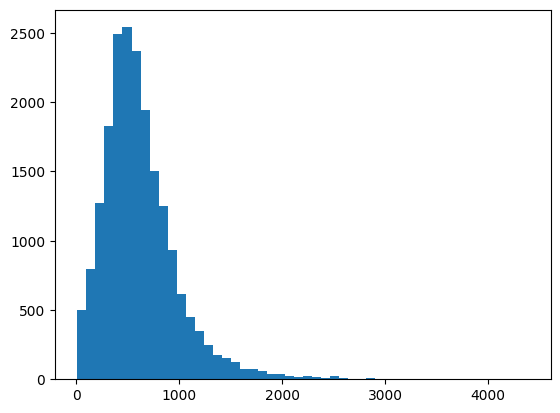

In [20]:
land_mask = pro_elevations > sea_level
helpers.describe_array(precipitation_mm[land_mask], plot=True)

In [21]:
slopes_array[land_mask] = np.power(slopes_array[land_mask], .9)
np.random.seed(SEED)
capacity = 1200 - np.random.exponential(scale=50, size=len(points)) * slopes_array
flow_graph_mm, saturation = hydrology.compute_flow_volume(drainage_array, precipitation_mm, absorption_array, slopes_array, capacity, evaporation)
rivers, hydrology = hydrology.infer_hydrology(elevations_m, flow_graph_mm, basin_relationships, drainage_array)

NameError: name 'basin_relationships' is not defined

In [ ]:
biome_mapping = {**ecology.sample_biome_mapping}
biome_mapping[8]['features']['mean']['s'] = .3
biome_mapping[9]['features']['mean']['s'] = .3
biome_mapping[6]['features']['mean']['p'] = 2800
biome_mapping[6]['features']['std_dev']['p_spread'] = 300
biome_mapping[6]['features']['mean']['s'] = .65
biome_mapping[6]['features']['std_dev']['s_spread'] = .3
biome_mapping[7]['features']['std_dev']['p_spread'] = 200
biome_mapping[3]['features']['mean']['p'] = 100
biome_mapping[3]['features']['std_dev']['p_spread'] = 200
biome_mapping[5]['features']['mean']['p'] = 600
biome_mapping[5]['features']['std_dev']['p_spread'] = 200
biome_mapping[5]['features']['std_dev']['s_spread'] = .15
biome_mapping[13]['features']['std_dev']['s_spread'] = .16
biome_mapping[13]['features']['mean']['s'] = 1.15
biome_mapping[13]['features']['std_dev']['p_spread'] = 150
biome_mapping[13]['features']['mean']['p'] = 1900
biome_mapping[14]['features']['std_dev']['p_spread'] = 150
biome_mapping[14]['features']['mean']['p'] = 1900
biome_mapping[14]['features']['std_dev']['s_spread'] = .16
biome_mapping[14]['features']['mean']['s'] = 1.15
biome_mapping[15]['features']['std_dev']['s_spread'] = .16
biome_mapping[15]['features']['mean']['s'] = 1.15
biome_mapping[15]['features']['std_dev']['p_spread'] = 150
biome_mapping

In [ ]:
effective_precipitation_mm = precipitation_mm + rivers * .08
biomes = ecology.infer_biomes(elevations_m, temperatures_c, effective_precipitation_mm, saturation, biome_mapping)

In [ ]:
def get_max(l: list[int | float]):
    max = 0
    max_i = None
    for i, n in enumerate(l):
        if len(n) > max:
            max = len(n)
            max_i = i
    return max, max_i

max, i = get_max(adjacency_graph.values())

In [ ]:
ids, counts = np.unique_counts(biomes[pro_elevations > sea_level])
total = sum(counts)
percentages = counts/total
for id, fraction in zip(ids, percentages):
    print(f'{ecology.sample_biome_mapping[id]['name']} = {fraction * 100:.2f}')

In [ ]:
def build_drainage_segments_sv(drainage_array: np.array, regions_to_ridge_points: dict):
    end_segments = { idx: pointer_idx for idx, pointer_idx in enumerate(drainage_array) if pointer_idx not in [-1, -2, -3] and drainage_array[pointer_idx] == -2 }
    midpoints = { idx: list(regions_to_ridge_points[tuple(sorted([idx, pointer_idx]))]) for idx, pointer_idx in end_segments.items() }
    segments = {}

    for idx, pointer_idx in enumerate(drainage_array):
        if pointer_idx in [-1, -2, -3]:
            continue

        if idx in midpoints:
            end = midpoints[idx]
        else:
            end = pointer_idx
        segments[idx] = end

    return segments

drainage_segments = build_drainage_segments_sv(drainage_array, inv_ridge_points)

def create_segments(start, end):
    offset = len(start)
    vertices = np.concatenate([start, end])
    return vertices, {idx: idx+offset for idx, val in enumerate(end)}, offset

In [ ]:
def polygons_to_triangles(regions):
    i_idx, j_idx, k_idx = [], [], []

    for region in regions:
        anchor = region[0]
        for n in range(1, len(region) -1):
            i_idx.append(anchor)
            j_idx.append(region[n])
            k_idx.append(region[n+1])

    return np.array(i_idx), np.array(j_idx), np.array(k_idx)

def map_regions_to_vertex(regions):
    vertices_map = {v: set() for region in regions for v in region}
    for idx, region in enumerate(regions):
        for vertex in region:
            vertices_map[vertex].add(idx)

    return vertices_map    

def map_intensity(regions, values):
    intensity = []
    for idx, region in enumerate(regions):
        num_triangles = len(region)
        intensity.extend([values[idx]] * num_triangles)
    
    return np.array(intensity)

def map_facecolors(regions, labels, color_map):
    colors = []
    for region_idx, region in enumerate(regions):
        num_triangles = len(region)
        label = labels[region_idx]
        if label == -1:
            continue
        r, g, b, a = color_map.get(label, [128, 128, 128, 1])
        colors.extend([f'rgb({r},{g},{b})'] * num_triangles)
    
    return colors

def normalize_elevations(elevations, sea_level, land_top_percentile=90):
    land_mask = elevations > sea_level
    ocean_mask = ~land_mask

    max_e = np.percentile(elevations, land_top_percentile)
    min_e = np.percentile(elevations, 1)

    normalized = np.zeros(len(elevations))
    normalized[ocean_mask] = np.clip((elevations[ocean_mask] - min_e) / (sea_level - min_e) * .5, 0, 0.5)
    normalized[land_mask] = np.clip(0.5 + (elevations[land_mask] - sea_level) / (max_e - sea_level) * 0.5, 0.5, 1)

    return normalized

terrain_colorscale =  [
        [0.0, 'darkblue'],
        [0.25, 'steelblue'],
        [0.5 - 1e-06, 'lightblue'],
        [0.5 + 1e-06, 'green'],
        [0.7, 'darkgreen'],
        [0.85, 'sienna'],
        [0.95, 'peru'],
        [1, 'white']
    ]

In [ ]:
def apply_terrain_to_vertices(regions, vertices, points, norm_elevations, scaling_factor=.1):
    topography_vertices = vertices.copy()
    topography_points = points.copy()
    vertices_by_region = map_regions_to_vertex(regions)
    displacement_coefficients = np.ones(len(np.concatenate((vertices, points))))
    vertices_offset = len(vertices)

    for vertex, regions in vertices_by_region.items():
        r = list(regions)
        magnitude = sum(norm_elevations[r] - 0.5) / len(r) * scaling_factor
        topography_vertices[vertex] = (vertices[vertex] * (1 + magnitude))
        displacement_coefficients[vertex] = 1 + magnitude

    for idx, point in enumerate(points):
        magnitude = (norm_elevations[idx] - 0.5) * scaling_factor
        topography_points[idx] = point * (1 + magnitude)
        displacement_coefficients[idx+vertices_offset] = 1 + magnitude

    return np.concatenate((topography_vertices, topography_points)), vertices_offset, displacement_coefficients

def get_triangles_w_centroids(regions, offset):
    i_idx, j_idx, k_idx = [], [], []
    triangle_to_regions_map = {}

    i = 0
    for idx, region in enumerate(regions):
        triangle_to_regions_map[idx] = []
        anchor = idx+offset
        for n in range(0, len(region)):
            i_idx.append(anchor)
            j_idx.append(region[n])
            k_idx.append(region[(n+1) % len(region)])
            triangle_to_regions_map[idx].append(i)
            i += 1

    return (np.array(i_idx), np.array(j_idx), np.array(k_idx)), triangle_to_regions_map

def create_sphere_topography(sv: SphericalVoronoi, normalized_elevations):
    terrain_vertices, offset, displacement = apply_terrain_to_vertices(sv.regions, sv.vertices, sv.points, normalized_elevations)
    terrain_triangles, triangle_to_region_map = get_triangles_w_centroids(sv.regions, offset)

    return sn(
        vertices=terrain_vertices,
        triangles=terrain_triangles,
        vertices_offset=offset,
        vertices_displacement=displacement,
        triangle_to_region_map=triangle_to_region_map
        )

def create_terrain_mesh(vertices, triangles, custom_data):
    x, y, z = vertices.T
    i, j, k = triangles

    return go.Mesh3d(
        x=x, y=y, z=z,
        i=i, j=j, k=k,
        flatshading=True,
        customdata=custom_data,
        hovertemplate=(
            "Region id: %{customdata[0]}<br>"
            "Elevation: %{customdata[1]}<br>"
            "Watershed: %{customdata[2]}<br>"
            "Continet: %{customdata[3]}<br>"
            "Temperature (C): %{customdata[4]}<br>"
            "Biome: %{customdata[5]}<br>"
            "Precipitation (mm/year): %{customdata[6]}<br>"
            "<extra></extra>"
        )
    )

def create_water_level_mesh(vertices, regions):
    x, y, z = vertices.T
    i, j, k = polygons_to_triangles(regions)
    return  go.Mesh3d(
            x=x, y=y, z=z,
            i=i, j=j, k=k,
            color='steelblue',
            opacity=0.4,
            flatshading=True,
            showscale=False
        )

def create_subset_mesh(regions, vertices, triangles, triangle_to_region, values, colorscale=None, facecolor=None, z_displacement=1.0001, opacity=.25, customdata=None):
    x, y, z = vertices.T * z_displacement
    i, j, k = triangles
    mask = np.array([idx for indices in np.where(values != -1)[0] for idx in triangle_to_region[indices]])
    
    if colorscale is not None:
        intensity = map_intensity(regions, values)[mask]

        return go.Mesh3d(
            x=x, y=y, z=z,
            i=i[mask], j=j[mask], k=k[mask],
            colorscale=colorscale,
            intensity=intensity,
            intensitymode='cell',
            opacity=opacity,
            flatshading=True,
            showscale=False,
            customdata=customdata
        )
    
    if facecolor is not None:
        colors = map_facecolors(regions, values, facecolor)

        return go.Mesh3d(
            x=x, y=y, z=z,
            i=i[mask], j=j[mask], k=k[mask],
            facecolor=colors,
            opacity=opacity,
            flatshading=True,
            showscale=False,
            customdata=customdata
        )



In [ ]:
def test(regions, vertices, terrain_vertices, triangles, elevations, sea_level, colorscale):
    x, y, z = terrain_vertices.T
    wx, wy, wz = vertices.T
    i, j, k = triangles
    wi, wj, wk = polygons_to_triangles(regions)
    norm_elevations = normalize_elevations(elevations, sea_level, 99.9)
    intensity = map_intensity(regions, norm_elevations)
    fig = go.Figure()

    fig.add_trace(go.Mesh3d(
            x=x, y=y, z=z,
            i=i, j=j, k=k,
            intensity=intensity,
            colorscale=colorscale,
            intensitymode='cell',
            flatshading=True
        ))

    fig.show(renderer='browser')

In [ ]:
def drainage_overlay(displaced_vertices: np.array, vertices_offset: int, segments: dict, volumes=None, width_multiplier=3, n_bins=8, color='steelblue', z_displacement=1.0001):
    if volumes is None:
        x, y, z, = [], [], []
        for start_idx, end_idx in segments.items():
            start_vector = displaced_vertices[vertices_offset+start_idx] * z_displacement
            if isinstance(end_idx, list):
                end_vector = displaced_vertices[end_idx].mean(axis=0) * z_displacement
            else:
                end_vector = displaced_vertices[vertices_offset+end_idx] * z_displacement

            x.extend([start_vector[0], end_vector[0], None])
            y.extend([start_vector[1], end_vector[1], None])
            z.extend([start_vector[2], end_vector[2], None])
        return go.Scatter3d(
            x=x, y=y, z=z, mode='lines',
            line=dict(color=color, width=3),
            showlegend=False, hoverinfo='skip'
        )
    
    vmin, vmax = volumes.min(), volumes.max()
    bins = np.linspace(0, width_multiplier, n_bins)
    grouped = {w: ([],[],[]) for w in bins}

    for start_idx, end_idx in segments.items():
        t = (volumes[start_idx] - vmin) / (vmax - vmin)
        width = bins[np.searchsorted(bins, t * width_multiplier) - 1]
        x, y, z = grouped[width]

        start_vector = displaced_vertices[vertices_offset+start_idx] * z_displacement
        if isinstance(end_idx, list):
            end_vector = displaced_vertices[end_idx].mean(axis=0) * z_displacement
        else:
            end_vector = displaced_vertices[vertices_offset+end_idx] * z_displacement
        
        x.extend([start_vector[0], end_vector[0], None])
        y.extend([start_vector[1], end_vector[1], None])
        z.extend([start_vector[2], end_vector[2], None])
    
    return [
        go.Scatter3d(
            x=x, y=y, z=z, mode='lines',
            line=dict(color=color, width=w),
            showlegend=False, hoverinfo='skip')
            for w, (x, y, z) in grouped.items() if x
    ]
    
def wind_overlay(vertices, segments, scale_factor=1, color='black', z_displacement=1.0001):
    x, y, z = [], [], []
    for origin, end in segments.items():
        origin_vector = vertices[origin] * z_displacement
        end_vector = vertices[end] * scale_factor + vertices[origin] * z_displacement
        
        x.extend([origin_vector[0], end_vector[0], None])
        y.extend([origin_vector[1], end_vector[1], None])
        z.extend([origin_vector[2], end_vector[2], None])
    return go.Scatter3d(
            x=x, y=y, z=z, mode='lines',
            line=dict(color=color, width=3),
            showlegend=False, hoverinfo='skip'
        )

In [ ]:
def apply_colorscale(mesh, regions, values, colorscale):
    
    trace = go.Mesh3d(mesh)
    trace.intensity = map_intensity(regions, values)
    trace.colorscale = colorscale
    trace.intensitymode = 'cell'
    
    return trace

def render_world(sv: SphericalVoronoi, sphere_topography, customdata, mesh_layers: list, overlay_traces, display_water_level=True):
    fig = go.Figure()

    base_mesh = create_terrain_mesh(sphere_topography.vertices, sphere_topography.triangles, customdata)
    fig.add_trace(base_mesh)

    for name, trace in overlay_traces:
        if isinstance(trace, list):
            fig.add_traces(trace)
        else:
            fig.add_trace(trace)

    mesh_buttons = [
        dict(label=name, method='restyle', args=[{'intensity': [map_intensity(sv.regions, intensity)], 'colorscale': [colorscale], 'intensitymode': ['cell']}, [0]]) for name, intensity, colorscale in mesh_layers
    ]

    overlay_buttons = [
        dict(label=name, method='restyle', args=[{'visible': True}, [i+1]], args2=[{'visible': False}, [i+1]]) for i, (name, _) in enumerate(overlay_traces)
    ]

    if display_water_level:
        water_idx = len(overlay_traces) + 1
        fig.add_trace(create_water_level_mesh(sv.vertices, sv.regions))
        overlay_buttons += [dict(label='Water', method='restyle', args=[{'visible': True}, [water_idx]], args2=[{'visible': False}, [water_idx]])]

    fig.update_layout(
        updatemenus=[
            dict(type='dropdown', y=1.1, buttons=mesh_buttons),
            dict(type='buttons', y=1.0, buttons=overlay_buttons)
    ])

    fig.show(renderer='browser')
    fig.write_html('world.html')

In [ ]:
custom = []
for region_idx, region in enumerate(sv.regions):
    num_triangles = len(region)  # with centroid anchor
    row = [
        region_idx,
        f"{pro_elevations[region_idx]:.2f}",
        watersheds[region_idx],
        new_continent_labels[region_idx],
        f"{temperatures_c[region_idx]:.2f}",
        ecology.sample_biome_mapping[biomes[region_idx]]['name'],
        f"{precipitation_mm[region_idx]:.2f}",
    ]
    custom.extend([row] * num_triangles)

customdata = np.array(custom)

norm_elevations = normalize_elevations(pro_elevations, sea_level, 99.9)
st = create_sphere_topography(sv, norm_elevations)
drainage_layer = drainage_overlay(st.vertices, st.vertices_offset, drainage_segments, rivers)
drainage_layer = drainage_overlay(**{'displaced_vertices': st.vertices, 'volumes':rivers, 'vertices_offset': st.vertices_offset,'segments': drainage_segments, 'z_displacement': 1.002})
watersheds_layer = create_subset_mesh(sv.regions, st.vertices, st.triangles, st.triangle_to_region_map, watersheds, colorscale='Turbo', opacity=1, customdata=customdata, z_displacement=1.002)
basin_layer = create_subset_mesh(sv.regions, st.vertices, st.triangles, st.triangle_to_region_map, basin_labels, colorscale='Turbo_r', opacity=1, customdata=customdata, z_displacement=1.0021)
biome_layer = create_subset_mesh(sv.regions, st.vertices, st.triangles, st.triangle_to_region_map, biomes, facecolor=ecology.sample_biome_colors, z_displacement=1.001, opacity=1, customdata=customdata)
#lake_layer = create_subset_mesh(sv.regions, st.vertices, st.triangles, st.triangle_to_region_map, lakes_array, facecolor={1: [55, 157, 204, 1]}, z_displacement=1.0021, opacity=1)

In [ ]:
render_world(
    sv,
    st,
    customdata,
    mesh_layers=[
        ('Terrain', norm_elevations, terrain_colorscale),
        ('Continents', new_continent_labels, 'Turbo_r'),
        ('Temperatures', temperatures_c, 'RdBu_r'),
        ('Precipitation', precipitation_mm, 'Blues'),
        
    ],
    overlay_traces=[
        #('Drainage', drainage_layer),
        ('Biomes', biome_layer),
        #('Watersheds', watersheds_layer),
        #('Basins', basin_layer),
        #('Lakes', lake_layer),
    ],
    display_water_level=True
)

In [ ]:
helpers.describe_array(rivers[land_mask], plot=True)

In [ ]:
helpers.describe_array(rivers[land_mask] / rivers[land_mask].mean(), plot=True)

In [ ]:
def compute_voronoi_areas_r1(points, regions, vertices):
    '''
    For unit sphere (r=1)
    '''
    areas = np.zeros(len(points))
    for idx, region in enumerate(regions):
        a = sv.points[idx]
        for i, vertex in enumerate(region):
            b = vertices[vertex]
            c = vertices[region[(i+1) % len(region)]]
            cross = np.cross(b - a, c - a)
            areas[idx] += 0.5 * np.linalg.norm(cross)
    return areas

areas = compute_voronoi_areas_r1(sv.points, sv.regions, sv.vertices)

In [ ]:
real_R = 1000
areas_km = areas * (real_R**2)

In [ ]:
rivers_m3s = (rivers * areas_km * 1000) / 31536000
helpers.describe_array(rivers_m3s[land_mask], plot=True)

In [ ]:
import json

def serialize_world(r: float,
                    points: list,
                    regions: list,
                    vertices: list,
                    elevations_m: list , temperatures_c, precipitation_mm: list, biome_keys: dict, biomes: list, drainage_graph: dict, river_throughput: dict, lakes_labels, lakes_depth, adjacency: dict):
    data = dict(radius=r,
                geometry=dict(
                    centroids=points,
                    regions=regions,
                    vertices=vertices,
                    adjacency=adjacency
                ),
                geography=dict(
                    elevations_m=elevations_m,
                    temperatures_c=temperatures_c,
                    precipitation_mmy=precipitation_mm,
                    boimes=biomes
                ),
                hydrology=dict(
                    river_throughput=river_throughput,
                    drainage_graph=drainage_graph,
                    lakes=lakes_labels,
                    lakes_depth=lakes_depth
                )
            )
    with open('map_data.json', 'w') as output:
        json.dump(data, output, indent=4, sort_keys=False)

In [ ]:
regions = [None] * len(sv.regions)
for i, region in enumerate(sv.regions):
    regions[i] = [int(idx) for idx in region]

adjacency_graph_list = {idx: list([int(i) for i in adj]) for idx, adj in adjacency_graph.items()}

biome_keys = {id: data['name'] for id, data in biome_mapping.items()}

river_throughput = {idx: throughput for idx, throughput in enumerate(rivers_m3s) if elevations_m[idx] > 0 }
drainage_graph = {idx: int(drain) for idx, drain in enumerate(drainage_array) if elevations_m[idx] > 0}

In [ ]:
merged_inland_sinks = hydrology.merge_adjacent_sinks([idx for idx, val in enumerate(drainage_array) if val == -1], adjacency_graph)

In [27]:
watersheds_sink_labels = { sink : drainage_array[sink] for sink in np.unique(watersheds) if sink != -1 }
watersheds_sink_labels

{np.int32(13): np.int32(-2),
 np.int32(24): np.int32(-1),
 np.int32(47): np.int32(-2),
 np.int32(49): np.int32(-2),
 np.int32(74): np.int32(-2),
 np.int32(106): np.int32(-2),
 np.int32(148): np.int32(-1),
 np.int32(151): np.int32(-1),
 np.int32(233): np.int32(-2),
 np.int32(238): np.int32(-1),
 np.int32(284): np.int32(-2),
 np.int32(322): np.int32(-1),
 np.int32(333): np.int32(-2),
 np.int32(347): np.int32(-1),
 np.int32(395): np.int32(-2),
 np.int32(408): np.int32(-2),
 np.int32(437): np.int32(-1),
 np.int32(456): np.int32(-1),
 np.int32(493): np.int32(-2),
 np.int32(504): np.int32(-2),
 np.int32(508): np.int32(-2),
 np.int32(512): np.int32(-1),
 np.int32(529): np.int32(-2),
 np.int32(535): np.int32(-2),
 np.int32(550): np.int32(-2),
 np.int32(569): np.int32(-2),
 np.int32(572): np.int32(-1),
 np.int32(577): np.int32(-1),
 np.int32(591): np.int32(-1),
 np.int32(605): np.int32(-2),
 np.int32(623): np.int32(-2),
 np.int32(646): np.int32(-1),
 np.int32(687): np.int32(-2),
 np.int32(716):

In [ ]:
sink = 27606

visit_order = []
members = []
exit = None
spill_at = []
spill_to = []
current_water_elev = pro_elevations[sink]
current = sink

while current:

    if pro_elevations[current] <= current_water_elev:
        if watersheds_sink_labels[watersheds[current]] == -2:
            exit = next(m for m in members if current in land_adjacency[m])
            spill_at.append(exit)
            spill_to.append(current)
            break
        elif watersheds_sink_labels[watersheds[current]] == -1 and watersheds[current] != sink:
            if exit is None:
                members.append(current)
        else:
            members.append(current)
    elif pro_elevations[current] > current_water_elev:
        if exit is None:
            current_water_elev = pro_elevations[current]
            members.append(current)
    
    for neighbor in land_adjacency[current]:
        if neighbor in members or (pro_elevations[neighbor], neighbor) in visit_order:
            continue
        
        heapq.heappush(visit_order, (pro_elevations[neighbor], neighbor))

    elev, idx = heapq.heappop(visit_order)
    current = idx

print(exit)
print(spill_at)
print(spill_to)
print(members)

In [107]:
inland_sinks = sorted([idx for idx, val in enumerate(drainage_array) if val == -1], key=lambda i: pro_elevations[i], reverse=False)
watersheds_sink_labels = { sink : drainage_array[sink] for sink in np.unique(watersheds) if sink != -1 }

DRAIN_INLAND = -1
DRAIN_TO_OCEAN = -2

labels = {
    sink:
    {
        "id": i,
        "parent": None,
        "spill_at_to": [],
        "escape": None,
        "members": [],
        "member_sinks": [],
        "memeber_sink_type": [],
        "member_elevation": []
    } for i, sink in enumerate(inland_sinks)
}

for sink in inland_sinks:
    current_water_level = pro_elevations[sink]
    visit_order = []
    current = sink
    while current:
        current_sink = watersheds[current]
        if watersheds_sink_labels[current_sink] == DRAIN_TO_OCEAN and labels[sink]["escape"] is None:
            escape = next(m for m in labels[sink]["members"] if current in land_adjacency[m])
            labels[sink]["escape"] = escape
            labels[sink]["spill_at_to"].append(dict(at=dict(cell=escape, sink=watersheds[escape]), to=dict(cell=current, sink=current_sink)))
            
            break
        elif watersheds_sink_labels[current_sink] == DRAIN_INLAND and current_sink != sink:
            prev = next(m for m in labels[sink]["members"] if current in land_adjacency[m])
            spill_at_to = dict(at=dict(cell=prev, sink=watersheds[prev]), to=dict(cell=current, sink=current_sink))
            if labels[current_sink]["escape"] is not None:
                labels[sink]["parent"] = current_sink
                labels[sink]["escape"] = labels[current_sink]["escape"]
                labels[sink]["spill_at_to"].append(spill_at_to)
                break

        if pro_elevations[current] <= current_water_level:
            labels[sink]["members"].append(current)
            labels[sink]["member_sinks"].append(current_sink)
            labels[sink]["memeber_sink_type"].append(watersheds_sink_labels[current_sink])
            labels[sink]["member_elevation"].append(pro_elevations[current_sink])

        elif pro_elevations[current] > current_water_level:
            if labels[sink]["escape"] is None:
                    current_water_level = pro_elevations[current]
                    labels[sink]["members"].append(current)
                    labels[sink]["member_sinks"].append(current_sink)
                    labels[sink]["memeber_sink_type"].append(watersheds_sink_labels[current_sink])
                    labels[sink]["member_elevation"].append(pro_elevations[current])
            else:
                current_water_level = pro_elevations[labels[sink]["escape"]]

        for neighbor in land_adjacency[current]:
            if neighbor in labels[sink]["members"] or (pro_elevations[neighbor], neighbor) in visit_order:
                continue

            heapq.heappush(visit_order, (pro_elevations[neighbor], neighbor))

        elev, idx = heapq.heappop(visit_order)
        current = None
        if labels[sink]["escape"] is None or elev <= pro_elevations[labels[sink]["escape"]]:
            current = idx

In [120]:
labels.keys()

dict_keys([27606, 40981, 19573, 44143, 27179, 34187, 49284, 39823, 40351, 43342, 17371, 29032, 47584, 43410, 1379, 47811, 19502, 31000, 39514, 49220, 29600, 3072, 29790, 39215, 27833, 33950, 27177, 49338, 45238, 24937, 48015, 41480, 46504, 7985, 22364, 46285, 37352, 34064, 27316, 28154, 26155, 39822, 39490, 37978, 42779, 16513, 29863, 33676, 21881, 15351, 45790, 44656, 6136, 36096, 21521, 10515, 3703, 20076, 23622, 37287, 12728, 41731, 22092, 4331, 2014, 9872, 43314, 7238, 19799, 1571, 12752, 39023, 4215, 10332, 8202, 2572, 15176, 27166, 19589, 18000, 20544, 44790, 25189, 26400, 16992, 1516, 16009, 39227, 1266, 1145, 9124, 4799, 13216, 7540, 42231, 19947, 44387, 25804, 34256, 42037, 8100, 40243, 40760, 40851, 17967, 6728, 17712, 31590, 11279, 33054, 16842, 36520, 39601, 12194, 25309, 33744, 33767, 45902, 26608, 868, 46233, 17463, 16982, 17915, 36478, 10440, 32975, 44569, 38843, 31007, 6458, 31698, 14259, 49437, 5898, 31258, 40963, 43404, 14360, 11177, 23881, 47788, 47052, 40718, 31767,

In [128]:
c = 40981
print(labels[c])
for i in range(len(labels[c]['members'])):
    print(labels[c]['members'][i], labels[c]['member_elevation'][i], labels[c]['member_sinks'][i], labels[c]['memeber_sink_type'][i])

{'id': 1, 'parent': None, 'spill_at_to': [{'at': {'cell': np.int64(47096), 'sink': np.int32(17371)}, 'to': {'cell': np.int64(8099), 'sink': np.int32(43431)}}], 'escape': np.int64(47096), 'members': [40981, np.int64(21104), np.int64(8954), np.int64(34209), np.int64(22456), np.int64(37059), np.int64(47198), np.int64(3991), np.int64(27179), np.int64(38889), np.int64(44143), np.int64(28771), np.int64(29032), np.int64(15594), np.int64(33545), np.int64(2774), np.int64(10706), np.int64(3072), np.int64(25719), np.int64(46729), np.int64(47096), np.int64(17371)], 'member_sinks': [np.int32(40981), np.int32(40981), np.int32(40981), np.int32(40981), np.int32(40981), np.int32(27179), np.int32(27179), np.int32(27179), np.int32(27179), np.int32(44143), np.int32(44143), np.int32(44143), np.int32(29032), np.int32(44143), np.int32(44143), np.int32(40981), np.int32(29032), np.int32(3072), np.int32(3072), np.int32(3072), np.int32(17371), np.int32(17371)], 'memeber_sink_type': [np.int32(-1), np.int32(-1), n

In [130]:
for m in labels[c]['members']:
    ns = [n for n in land_adjacency[m] if n in labels[c]['members']]
    print(f'count:{ns}, cell:{m}, sink_id:{watersheds[m]}')

count:[np.int64(21104), np.int64(8954)], cell:40981, sink_id:40981
count:[np.int64(34209), np.int64(40981), np.int64(22456), np.int64(8954)], cell:21104, sink_id:40981
count:[np.int64(21104), np.int64(40981), np.int64(22456)], cell:8954, sink_id:40981
count:[np.int64(37059), np.int64(21104), np.int64(22456)], cell:34209, sink_id:40981
count:[np.int64(34209), np.int64(21104), np.int64(2774), np.int64(8954)], cell:22456, sink_id:40981
count:[np.int64(34209), np.int64(47198)], cell:37059, sink_id:27179
count:[np.int64(37059), np.int64(3991)], cell:47198, sink_id:27179
count:[np.int64(27179), np.int64(47198)], cell:3991, sink_id:27179
count:[np.int64(38889), np.int64(15594), np.int64(3991)], cell:27179, sink_id:27179
count:[np.int64(15594), np.int64(27179), np.int64(44143)], cell:38889, sink_id:44143
count:[np.int64(28771), np.int64(38889), np.int64(15594)], cell:44143, sink_id:44143
count:[np.int64(29032), np.int64(15594), np.int64(44143), np.int64(10706)], cell:28771, sink_id:44143
count

In [92]:
watersheds_sink_labels[43431]

np.int32(-2)

In [91]:
watersheds[8099]

np.int32(43431)

In [124]:
labels[27833]

{'id': 24,
 'parent': np.int32(43410),
 'spill_at_to': [{'at': {'cell': 27833, 'sink': np.int32(27833)},
   'to': {'cell': np.int64(21283), 'sink': np.int32(43410)}}],
 'escape': 43410,
 'members': [27833],
 'member_sinks': [np.int32(27833)],
 'memeber_sink_type': [np.int32(-1)],
 'member_elevation': [np.float64(1.5902227281577794)]}

In [88]:
labels[c]['escape']

np.int64(47096)

In [32]:
c = 8954
basin = [40981]
print(labels[40981])
print(pro_elevations[c])
print(land_adjacency[c])
print(pro_elevations[list(adjacency_graph[c])])
print(watersheds[list(adjacency_graph[c])])
print([(k, v) for k, v in watersheds_sink_labels.items() if k in np.unique(watersheds[list(adjacency_graph[c])])])

{'id': 1, 'parent': None, 'spill_at_to': [{'at': (np.int32(40981), np.int64(34209)), 'to': (np.int32(27179), np.int64(37059))}, {'at': (np.int32(27179), np.int64(37059)), 'to': (np.int32(27179), np.int64(47198))}, {'at': (np.int32(27179), np.int64(47198)), 'to': (np.int32(27179), np.int64(3991))}, {'at': (np.int32(27179), np.int64(3991)), 'to': (np.int32(27179), np.int64(27179))}, {'at': (np.int32(27179), np.int64(27179)), 'to': (np.int32(44143), np.int64(38889))}, {'at': (np.int32(44143), np.int64(38889)), 'to': (np.int32(44143), np.int64(44143))}, {'at': (np.int32(44143), np.int64(44143)), 'to': (np.int32(44143), np.int64(28771))}, {'at': (np.int32(44143), np.int64(28771)), 'to': (np.int32(29032), np.int64(29032))}, {'at': (np.int32(27179), np.int64(27179)), 'to': (np.int32(44143), np.int64(15594))}, {'at': (np.int32(44143), np.int64(15594)), 'to': (np.int32(44143), np.int64(33545))}, {'at': (np.int32(44143), np.int64(28771)), 'to': (np.int32(29032), np.int64(10706))}, {'at': (np.int

In [26]:
drainage_array[2518]

np.int32(-2)

In [ ]:
watersheds_sink_labels[44208]

In [ ]:
land_adjacency[27606]

In [ ]:
print(pro_elevations[21104])
print(land_adjacency[21104])
print(pro_elevations[list(adjacency_graph[21104])])

In [ ]:
print(pro_elevations[27606])
print(adjacency_graph[27606])
print(pro_elevations[list(adjacency_graph[27606])])

In [93]:
d = dict(a=dict(b=1, c=2), aa=dict(d=3, e=4))

In [94]:
d

{'a': {'b': 1, 'c': 2}, 'aa': {'d': 3, 'e': 4}}

In [105]:
a, b, = d

In [106]:
a, b

('a', 'aa')